In [2]:
pip install pandas deep-translator

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
from deep_translator import GoogleTranslator
import time
import os

# 1. Définition du chemin spécifique
# Le 'r' avant les guillemets permet de lire le chemin sans erreur d'interprétation des \
chemin_dossier = r'D:\Data_ML_PersonalWork'
nom_fichier = 'SMSSpamCollection'
chemin_complet = os.path.join(chemin_dossier, nom_fichier)

# 2. Chargement avec vérification
if not os.path.exists(chemin_complet):
    print(f"Erreur : Le fichier est introuvable au chemin : {chemin_complet}")
    exit()

df = pd.read_csv(chemin_complet, sep='\t', names=['label', 'text'])
df_small = df.head(1000).copy()
print(f"Fichier chargé avec succès depuis {chemin_dossier}")

# 3. Configuration du traducteur
translator = GoogleTranslator(source='en', target='mg')

def quick_translate(text):
    try:
        return translator.translate(text)
    except:
        return None

# 4. Lancement de la traduction
print("Traduction des 1000 premières lignes en cours...")
translated_list = []

for i, msg in enumerate(df_small['text']):
    res = quick_translate(msg)
    translated_list.append(res if res else msg)
    
    if (i + 1) % 100 == 0:
        print(f"Progression : {i + 1}/1000...")
        time.sleep(1)

# 5. Sauvegarde du résultat dans le MÊME dossier
df_small['text_mg'] = translated_list
df_final = df_small[['label', 'text_mg']]
chemin_sortie = os.path.join(chemin_dossier, 'test_1000_mg.csv')
df_final.to_csv(chemin_sortie, index=False, encoding='utf-8')

print(f"\nSuccès ! Le fichier traduit est ici : {chemin_sortie}")

Fichier chargé avec succès depuis D:\Data_ML_PersonalWork
Traduction des 1000 premières lignes en cours...
Progression : 100/1000...
Progression : 200/1000...
Progression : 300/1000...
Progression : 400/1000...
Progression : 500/1000...
Progression : 600/1000...
Progression : 700/1000...
Progression : 800/1000...
Progression : 900/1000...
Progression : 1000/1000...

Succès ! Le fichier traduit est ici : D:\Data_ML_PersonalWork\test_1000_mg.csv


In [6]:
import pandas as pd

# Charger le dataset généré
df = pd.read_csv(r'D:\Data_ML_PersonalWork\test_1000_mg.csv')

print("--- Aperçu de 5 Spams traduits ---")
print(df[df['label'] == 'spam']['text_mg'].head(20))

print("\n--- Aperçu de 5 Messages normaux (Ham) ---")
print(df[df['label'] == 'ham']['text_mg'].head(20))

# Vérifier s'il y a des lignes vides
print(f"\nNombre de lignes vides : {df['text_mg'].isnull().sum()}")

--- Aperçu de 5 Spams traduits ---
2      Fidirana maimaim-poana amin'ny comp 2 isan-ker...
5      FreeMsg Hey ry malala fa efa 3 herinandro izao...
8      MPANDRESY!! Amin'ny maha-mpanjifa tambajotra s...
9      Efa 11 volana na mihoatra ve ny findainao? UR ...
11     ENINA ny fahafahana hahazo CASH! Manomboka ami...
12     MAIKA! Nahazo ny maha-mpikambana MAIMAIM-POANA...
15     XXXMobileMovieClub: Raha hampiasa ny trosanao ...
19     Angleterre v Macedonia - aza adino ny tanjona ...
34     Misaotra anao tamin'ny famandrihanao Ringtone ...
42     07732584351 - Rodger Burns - MSG = Niezaka nia...
54     SMS. ac Sptv: Ny New Jersey Devils sy ny Detro...
56     Arahabaina! Ny pasipaoro manokana momba ny sin...
65     Amin'ny maha-mpanjifa sarobidy ahy, dia faly a...
67     Urgent UR dia nanome fitsangatsanganana maimai...
68     Nandre momba ny "Barbie Divorce" vaovao ve ian...
93     Azafady, antsoy ny solontenanay amin'ny serivi...
95     Miandry ny fanangonana ny ringtone maimaim-poa

In [9]:
print(f"data du TEST: {df.columns}" )

data du TEST: Index(['label', 'text_mg'], dtype='object')


In [10]:
print(f"data du TEST: {df.head}" )

data du TEST: <bound method NDFrame.head of     label                                            text_mg
0     ham  Mandehana hatramin'ny jurong point, adala.. Ts...
1     ham                   Ok lar... Mivazivazy raha oni...
2    spam  Fidirana maimaim-poana amin'ny comp 2 isan-ker...
3     ham                         Efa teneninao aloha hoe...
4     ham  Tsy heveriko fa mandeha any amin'ny usf izy fa...
..    ...                                                ...
995   ham            tsy azoko fa tsy manana numéro azy aho!
996   ham       Ovay indray... Eo akaikin'ny escalator io...
997   ham  Mbola ao an-dakilasy ve aho, tsy afaka manondr...
998   ham  Tsy dia betsaka no nitranga teto. Mahatsiaro t...
999   ham  Avy eo andraso 4 aho eo amin'ny fiantsonan'ny ...

[1000 rows x 2 columns]>


In [11]:
import pandas as pd

# 1. Charger ton dataset de base (les 1000 lignes traduites)
df = pd.read_csv(r'D:\Data_ML_PersonalWork\test_1000_mg.csv')
# Tes nouveaux exemples réels
nouveaux_spams = [
    {'label': 'spam', 'text_mg': "Mvola: Nahazo loka 500.000Ar ianao. Antsoy ny 0340000000 handraisana azy."},
    {'label': 'spam', 'text_mg': "Orange Money: Nahazo kadoa 200.000Ar ianao. Tsindrio ity lien ity: bit.ly/om-kadoa"},
    {'label': 'spam', 'text_mg': "Fampitandremana: Hidiana ny kaonty Airtel Money-nao. Antsoy ny laharana 0331265432"},
    {'label': 'spam', 'text_mg': "Nisy fahadisoana ny transfert nataoko taminao. Mba avereno amin'ity laharana ity ny vola"},
    {'label': 'spam', 'text_mg': "Mahazo crédit 5.000Ar maimaimpoana ianao. Alefaso ny laharana 0345697842"},
    {'label': 'spam', 'text_mg': "Félicitations! ianao dia Voafidy hahazo loka amin'ny Telma. Antsoy ny laharana 0387965412"},
    {'label': 'spam', 'text_mg': "Maika: Mila fanampiana ny havanao any amin'ny hopitaly. Alefaso vola haingana ny vola amin'ny laharana 0383475169"},
    {'label': 'spam', 'text_mg': "Mitady mpiasa maika izahay. Karama 800.000Ar isan-bolana. atsoy ity numero ity 0325879413"},
    {'label': 'spam', 'text_mg': "Nahazo Bonus 10Go ianao. Mba hampandehanana azy dia omeo ny kaody ny orange money anao"},
    {'label': 'ham', 'text_mg': "Efa tonga ve ianao? Miandry anao izahay eto an-trano."},
    {'label': 'ham', 'text_mg': "Miarahaba, aza adino ny mitondra ny kahie rahampitso. Misaotra."},
    {'label': 'ham', 'text_mg': "Manao ahoana, afaka miantso ve ianao fa misy zavatra kely horesahina?."},
    {'label': 'ham', 'text_mg': "Efa nalefako ny vola tamin'ny Mvola. Jereo ny SMS."},
    {'label': 'ham', 'text_mg': "Ho avy any an-trano aho amin'ny 6 ora hariva."},
    {'label': 'ham', 'text_mg': "salama, afaka mba raisiao ve ny appelak azfd."},
    {'label': 'ham', 'text_mg': "ts tafandal zah raikitra b."},
    {'label': 'spam', 'text_mg': "Felicitation!, ianao dia voasarika tamin'ny lalao tombola nokarakarain'ny SIRAMA, atsoy ity numero ity 0345697264"},
    {'label': 'ham', 'text_mg': "handeha hak an'le entana zah av ew"},
    {'label': 'spam', 'text_mg': "Arahabaina ianao dia voasarika tamin'ny lalao nokarakarain'ny tranombarotra MORA PRIX, ka mba afahanao maka ilay loka de antsoy ity numero ity 0336974231"},
    {'label': 'ham', 'text_mg': "ndw am zay"},
    {'label': 'spam', 'text_mg': "Felicitation!, ianao dia nahazo 4*4 avy amin'ny SIRAMA, atsoy ity numero ity hakanao azy 0345972103"},
    {'label': 'spam', 'text_mg': "Arahabaina!, ianao dia nahazo vola 100.000.000ar avy amin'ny YAS, ka atsoy ity numero ity 0324769212"},
    {'label': 'ham', 'text_mg': "tsara tarehy ilay vehivavy"},
    {'label': 'spam', 'text_mg': "Felicitation!, ianao dia nahazo vola 7.000.000.000 tamin'ny societe SOMAVA, ka atsoy ity numero ity 0387965423"},
    {'label': 'spam', 'text_mg': "Felicitation!, ianao dia voasarika tamin'ny lalao tombola nokarakarain'ny TELMA, atsoy ity numero ity 0345667264"},
    {'label': 'ham', 'text_mg': "mandehana at antran "},
    {'label': 'ham', 'text_mg': "ok"},
    {'label': 'ham', 'text_mg': "ok, mandeh ilay compte"},
    {'label': 'ham', 'text_mg': "slm, ve ianao?"},
    {'label': 'spam', 'text_mg': "Felicitation!, ianao dia nahazo 4*4 avy amin'ny SOMAVA, atsoy ity numero ity hakanao azy 0345972103"},
    {'label': 'spam', 'text_mg': "Felicitation!, ianao dia voasarika tamin'ny lalao tombola nokarakarain'ny SIRAMA, atsoy ity numero ity 0345696264"},
    {'label': 'ham', 'text_mg': "Miarahaba tompoko!, aza omena olona ny kaody nao "},
    {'label': 'spam', 'text_mg': "Miarahaba tompoko!, ianao dia voasarika nahazo 4*4, ka atsoy ity numero ity 0334597618"},
    {'label': 'ham', 'text_mg': "millw le zaz ka!"},
    {'label': 'ham', 'text_mg': "ok, voaraiko ilay vola tompoko."},
    {'label': 'spam', 'text_mg': "Felicitations!, ianao dia nahazo trano avy amin'ny orinasa SOMAVA, atsoy ity numero ity hakanao azy 0345972103"},
    {'label': 'ham', 'text_mg': "mandeha ilay compte tompoko"},
    
]

df_reels = pd.DataFrame(nouveaux_spams)

# 3. Fusion avec le dataset de test
df_final = pd.concat([df, df_reels], ignore_index=True)

# --- CORRECTION CRUCIALE ---
# On met tous les labels en minuscules pour éviter d'avoir 'Spam' et 'spam'
df_final['label'] = df_final['label'].str.lower()

# On supprime les éventuels doublons (si tu as exécuté le code plusieurs fois)
df_final = df_final.drop_duplicates(subset=['text_mg'])

# 4. Sauvegarde finale
df_final.to_csv(r'D:\Data_ML_PersonalWork\dataset_final_mg.csv', index=False, encoding='utf-8')

print(f"Terminé ! Nouveau total : {len(df_final)} messages.")
print("Vérification des labels :", df_final['label'].unique())

Terminé ! Nouveau total : 1013 messages.
Vérification des labels : ['ham' 'spam']


In [13]:
import pandas as pd
df_final = pd.read_csv(r'D:\Data_ML_PersonalWork\dataset_final_mg.csv')

# Affiche les 10 dernières lignes pour voir tes ajouts
print(df_final.tail(10))

# Compte combien de spams tu as maintenant
print("\nNombre total de spams :", len(df_final[df_final['label'] == 'spam']))

     label                                            text_mg
1003   ham                             ok, mandeh ilay compte
1004   ham                                     slm, ve ianao?
1005  spam  Felicitation!, ianao dia nahazo 4*4 avy amin'n...
1006  spam  Felicitation!, ianao dia voasarika tamin'ny la...
1007   ham  Miarahaba tompoko!, aza omena olona ny kaody nao 
1008  spam  Miarahaba tompoko!, ianao dia voasarika nahazo...
1009   ham                                   millw le zaz ka!
1010   ham                    ok, voaraiko ilay vola tompoko.
1011  spam  Felicitations!, ianao dia nahazo trano avy ami...
1012   ham                        mandeha ilay compte tompoko

Nombre total de spams : 847


label
ham     847
spam    166
Name: count, dtype: int64


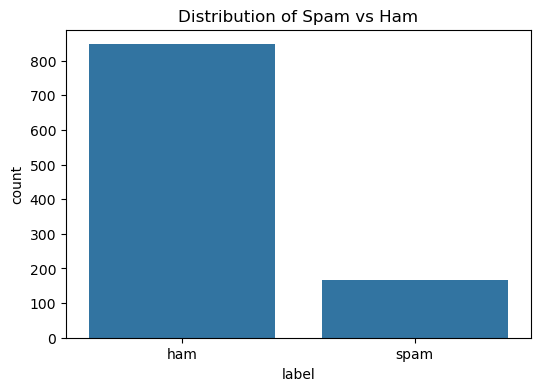

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
print(df_final['label'].value_counts())

# Visualize it
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df_final)
plt.title("Distribution of Spam vs Ham")
plt.show()